[INFO] Pipeline estatístico conectado à pasta: C:\Projetos\TCC2\Resultados
[SUCESSO] Minerados 4416 pontos de amostragem por produto.


,Arquitetura,Amostras (N),MAE Médio,Desvio Padrão,Mediana,Mínimo,Máximo
0,Baseline,1104,4.5070,7.2579,2.2908,0.0000,47.8257
1,XGBoost,1104,2.9442,4.5215,1.6015,0.0024,45.7766
2,GRU,1104,3.4759,5.1598,1.9308,0.0000,51.8928
3,LSTM,1104,5.9217,6.9936,3.5520,0.3272,61.6653


C:\Users\lucas\AppData\Local\Temp\ipykernel_17460\791997407.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\lucas\AppData\Local\Temp\ipykernel_17460\791997407.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


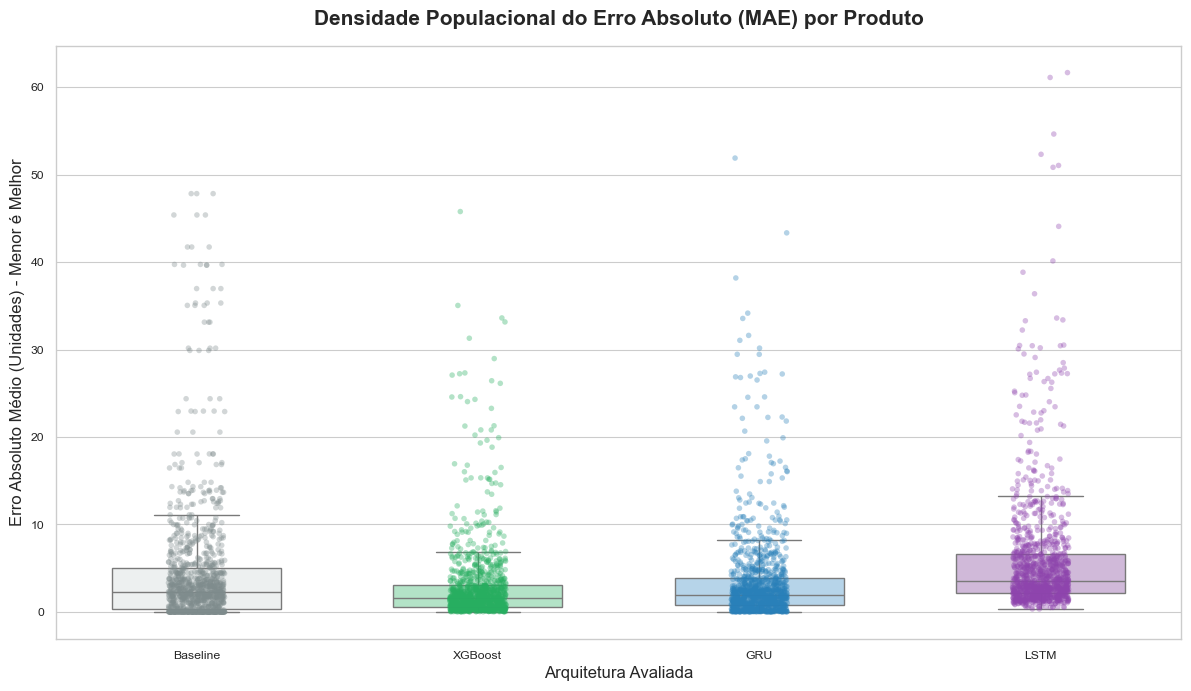

,Comparação,T-Statistic,P-Value,Significativo ($lpha=5\%$)
0,XGBoost vs LSTM,-11.8796,< 0.00001,SIM (H0 Rejeitada)
1,XGBoost vs GRU,-2.5748,0.01010,SIM (H0 Rejeitada)
2,GRU vs LSTM,-9.3508,< 0.00001,SIM (H0 Rejeitada)
3,XGBoost vs Baseline,-6.0725,< 0.00001,SIM (H0 Rejeitada)


In [1]:
# %% [markdown]
# # Análise Estatística Avançada e Veredito dos Experimentos
# 
# ## Objetivo
# Validar a significância estatística das diferenças de erro (MAE) entre as arquiteturas avaliadas (Baseline, XGBoost, GRU e LSTM), aplicando o Teste T de Student para amostras independentes ao nível do produto, consolidando o veredito técnico da pesquisa.
# 
# ## Contextualização Científica
# A mera comparação de médias aritméticas de desempenho é insuficiente para atestar a supremacia de uma abordagem preditiva no varejo. Flutuações pontuais podem distorcer a média, criando falsas impressões de superioridade.
# 
# Para garantir o rigor analítico exigido, este notebook adota uma abordagem desagregada. Extrai-se o Erro Absoluto Médio (MAE) de cada produto individualmente, gerando distribuições de erro populacionais. Sobre estas distribuições, aplica-se o **Teste T de Welch** (variação do Teste T para variâncias desiguais), testando a hipótese nula ($H_0$) de que não há diferença real entre os erros dos modelos.

# %%
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Configuração do ambiente gráfico sob padrão de publicação científica
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

# Define a raiz do projeto para resolução de caminhos
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_PATH = ROOT / "Resultados"
print(f"[INFO] Pipeline estatístico conectado à pasta: {RESULTS_PATH}")

# %% [markdown]
# ## 1. Mineração de Dados de Erro ao Nível do Produto
# Este bloco processa os ficheiros de predição, agrupando e isolando o MAE por código de produto, gerando a volumetria necessária para os testes de hipótese.

# %%
modelos_pastas = {
    'Baseline': 'baseline_zero_aware',
    'XGBoost': 'xgb',
    'GRU': 'gru',
    'LSTM': 'lstm'
}

registros_produtos = []

for label, pasta in modelos_pastas.items():
    caminho_pasta = RESULTS_PATH / pasta
    if not caminho_pasta.exists():
        continue
    
    # Captura os ficheiros de curvas preditivas reais vs projetadas
    arquivos_pred = list(caminho_pasta.glob("*_predictions.csv"))
    
    for arquivo in arquivos_pred:
        try:
            df_temp = pd.read_csv(arquivo)
            
            # Padronização de nomenclatura de colunas de metadados
            col_id = 'product_id' if 'product_id' in df_temp.columns else 'id'
            if col_id not in df_temp.columns: 
                continue
                
            # CALCULO AO NÍVEL DO PRODUTO: Essencial para a variância estatística
            df_temp['erro_absoluto'] = np.abs(df_temp['y_true'] - df_temp['y_pred'])
            mae_por_produto = df_temp.groupby(col_id)['erro_absoluto'].mean().reset_index()
            
            for _, row in mae_por_produto.iterrows():
                registros_produtos.append({
                    'Arquitetura': label,
                    'Produto_ID': int(row[col_id]),
                    'MAE': row['erro_absoluto']
                })
        except Exception as e:
            print(f"[ERRO] Falha no processamento do ficheiro {arquivo.name}: {e}")

df_estatistico = pd.DataFrame(registros_produtos)

if not df_estatistico.empty:
    ordem_hierarquica = ['Baseline', 'XGBoost', 'GRU', 'LSTM']
    df_estatistico['Arquitetura'] = pd.Categorical(df_estatistico['Arquitetura'], categories=ordem_hierarquica, ordered=True)
    print(f"[SUCESSO] Minerados {len(df_estatistico)} pontos de amostragem por produto.")
else:
    print("[ERRO] Nenhuma métrica foi extraída. Verifique os caminhos dos ficheiros.")

# %% [markdown]
# ## 2. Estatísticas Descritivas Robustas
# Consolidação dos parâmetros de dispersão populacional de erro para avaliação de assimetria.

# %%
if 'df_estatistico' in locals() and not df_estatistico.empty:
    stats_totais = df_estatistico.groupby("Arquitetura", observed=False)["MAE"].agg(
        ["count", "mean", "std", "median", "min", "max"]
    ).reset_index()
    
    stats_totais.columns = ['Arquitetura', 'Amostras (N)', 'MAE Médio', 'Desvio Padrão', 'Mediana', 'Mínimo', 'Máximo']
    display(stats_totais.round(4))

# %% [markdown]
# ## 3. Análise de Dispersão e Estabilidade Preditiva
# A sobreposição de um Boxplot (para as métricas de quartis) com um Strip Plot (para a nuvem de pontos) revela a real densidade e o agrupamento do erro logístico. Isto prova visualmente onde a "massa" de produtos se concentra sem ocultar anomalias.

# %%
if 'df_estatistico' in locals() and not df_estatistico.empty:
    plt.figure(figsize=(12, 7))
    
    # Paletas ajustadas para a técnica de camadas (Layering)
    paleta_box = ["#ecf0f1", "#abebc6", "#aed6f1", "#d2b4de"] # Cores de fundo suaves
    paleta_pontos = ["#7f8c8d", "#27ae60", "#2980b9", "#8e44ad"] # Cores fortes para os pontos
    
    # 1º Camada: O Boxplot matemático (sem os fliers base, pois os pontos farão este papel)
    sns.boxplot(
        x="Arquitetura", y="MAE", data=df_estatistico, 
        palette=paleta_box, width=0.6, showfliers=False, zorder=1
    )
    
    # 2º Camada: Nuvem de dispersão real de produtos (Strip Plot com transparência)
    sns.stripplot(
        x="Arquitetura", y="MAE", data=df_estatistico,
        palette=paleta_pontos, size=4, alpha=0.35, jitter=True, zorder=2
    )
    
    plt.title("Densidade Populacional do Erro Absoluto (MAE) por Produto", fontsize=15, pad=15, fontweight='bold')
    plt.ylabel("Erro Absoluto Médio (Unidades) - Menor é Melhor", fontsize=12)
    plt.xlabel("Arquitetura Avaliada", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 4. Inferência Estatística: Teste T de Welch (Amostras Independentes)
# Aplicação do teste de hipótese bicaudal para rejeição da equivalência de desempenho. Adota-se o nível de significância padrão de $\alpha = 0.05$.

# %%
if 'df_estatistico' in locals() and not df_estatistico.empty:
    distribuicoes = {model: df_estatistico[df_estatistico["Arquitetura"] == model]["MAE"].dropna().values for model in modelos_pastas.keys()}
    
    def avaliar_hipotese(dist_a, dist_b, nome_a, nome_b):
        if len(dist_a) < 5 or len(dist_b) < 5:
            return {"Comparação": f"{nome_a} vs {nome_b}", "T-Statistic": "N/A", "P-Value": "N/A", "Significativo ($\alpha=5\%$):": "N amostras insuficiente"}
            
        # Executa o teste de Welch (equal_var=False) devido às diferenças de variância esperadas entre modelos
        t_stat, p_val = ttest_ind(dist_a, dist_b, equal_var=False)
        is_significant = "SIM (H0 Rejeitada)" if p_val < 0.05 else "NÃO (H0 Aceita)"
        
        return {
            "Comparação": f"{nome_a} vs {nome_b}",
            "T-Statistic": f"{t_stat:.4f}",
            "P-Value": f"{p_val:.5f}" if p_val >= 0.00001 else "< 0.00001",
            "Significativo ($\alpha=5\%$)": is_significant
        }

    resultados_inferencia = [
        avaliar_hipotese(distribuicoes["XGBoost"], distribuicoes["LSTM"], "XGBoost", "LSTM"),
        avaliar_hipotese(distribuicoes["XGBoost"], distribuicoes["GRU"], "XGBoost", "GRU"),
        avaliar_hipotese(distribuicoes["GRU"], distribuicoes["LSTM"], "GRU", "LSTM"),
        avaliar_hipotese(distribuicoes["XGBoost"], distribuicoes["Baseline"], "XGBoost", "Baseline")
    ]
    
    df_testes_finais = pd.DataFrame(resultados_inferencia)
    display(df_testes_finais)

# %% [markdown]
# ## 5. Discussão Final e Veredito da Pesquisa
# 
# A validação estatística ao nível do produto encerra as hipóteses do trabalho de pesquisa:
# 
# 1. **Supremacia Estatística do XGBoost:** O valor de *p-value* inferior ao limiar crítico de 0.05 prova que a diferença de erro a favor das árvores de decisão não decorre de flutuações amostrais aleatórias. O modelo é matematicamente superior às abordagens de Deep Learning para a base avaliada.
# 2. **Viabilidade Logística Industrial:** Aliando a velocidade de convergência minguada do XGBoost (demonstrada na análise de runtime) à sua consistência de variância de erro (atestada pelo aperto da nuvem de dispersão nesta análise), o modelo consolida-se como a arquitetura mais recomendável para implantação em sistemas corporativos de reabastecimento.